In [1]:
import pandas as pd

In [19]:
df_train = pd.read_csv(r"C:\Users\Aditya P J\Documents\Competition\Kaggle\Flood Prediction\train.csv")
pd.set_option('display.max_columns', None)
df_train

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,4,2,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,6,9,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,5,6,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,8,5,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,3,5,2,2,6,6,4,1,2,3,5,0.415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117952,1117952,3,3,4,10,4,5,5,7,10,4,3,7,8,7,2,2,1,4,6,4,0.495
1117953,1117953,2,2,4,3,9,5,8,1,3,5,5,9,4,4,3,7,4,9,4,5,0.480
1117954,1117954,7,3,9,4,6,5,9,1,3,4,5,5,5,5,5,6,5,5,2,4,0.485
1117955,1117955,7,3,3,7,5,2,3,4,6,4,6,6,8,5,3,4,6,7,6,4,0.495


In [21]:
df_test = pd.read_csv(r"C:\Users\Aditya P J\Documents\Competition\Kaggle\Flood Prediction\test.csv")
df_test

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
0,1117957,4,6,3,5,6,7,8,7,8,4,8,5,7,5,6,3,6,4,4,5
1,1117958,4,4,2,9,5,5,4,7,5,4,2,4,7,4,5,1,7,4,4,3
2,1117959,1,3,6,5,7,2,4,6,4,2,7,9,2,5,5,2,3,6,8,3
3,1117960,2,4,4,6,4,5,4,3,4,4,7,8,4,6,7,6,4,2,4,4
4,1117961,6,3,2,4,6,4,5,5,3,7,4,3,2,6,4,6,8,4,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745300,1863257,5,4,8,3,5,4,4,5,5,5,5,6,1,3,5,6,4,4,6,6
745301,1863258,4,4,2,12,4,3,4,3,5,5,3,7,4,4,3,5,5,3,5,4
745302,1863259,5,7,9,5,5,6,7,5,5,3,6,11,3,11,4,5,9,5,5,4
745303,1863260,4,7,6,3,5,2,3,8,6,7,6,6,8,6,2,3,8,7,5,5


## Data Cleaning dan Transformation

In [25]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  1117957 non-null 

In [35]:
# Mengatur format display agar tidak menggunakan scientific notation
pd.options.display.float_format = '{:.2f}'.format
df_train.describe(include='all')

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00
mean,558978.00,4.92,4.93,4.96,4.94,4.94,4.93,4.96,4.93,4.94,4.95,4.95,4.95,4.95,4.93,4.93,4.93,4.93,4.95,4.94,4.94,0.50
std,322726.53,2.06,2.09,2.07,2.05,2.08,2.06,2.08,2.07,2.07,2.08,2.08,2.07,2.09,2.08,2.08,2.06,2.07,2.07,2.08,2.09,0.05
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.28
25%,279489.00,3.00,3.00,4.00,4.00,3.00,3.00,4.00,3.00,3.00,4.00,3.00,4.00,3.00,3.00,3.00,3.00,3.00,4.00,3.00,3.00,0.47
50%,558978.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.51
75%,838467.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,0.54
max,1117956.00,16.00,18.00,16.00,17.00,17.00,17.00,16.00,16.00,16.00,18.00,16.00,17.00,17.00,16.00,16.00,17.00,18.00,19.00,16.00,16.00,0.72


In [31]:
missing_values = df_train.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

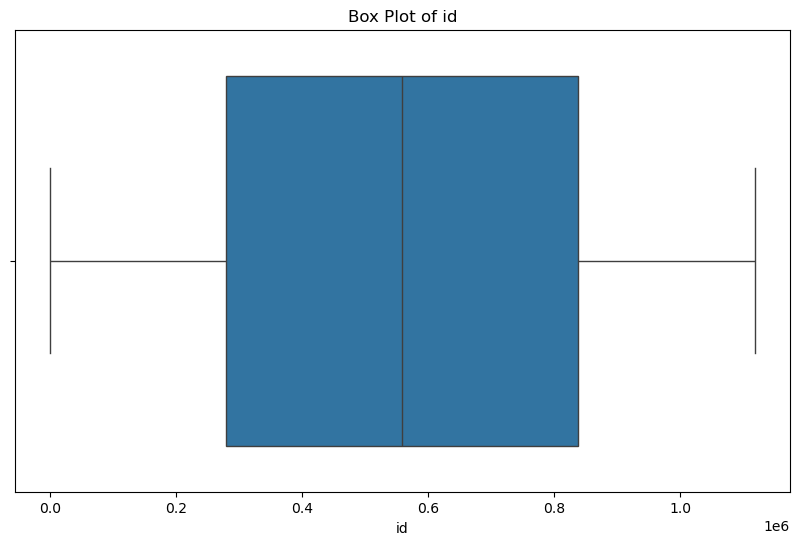

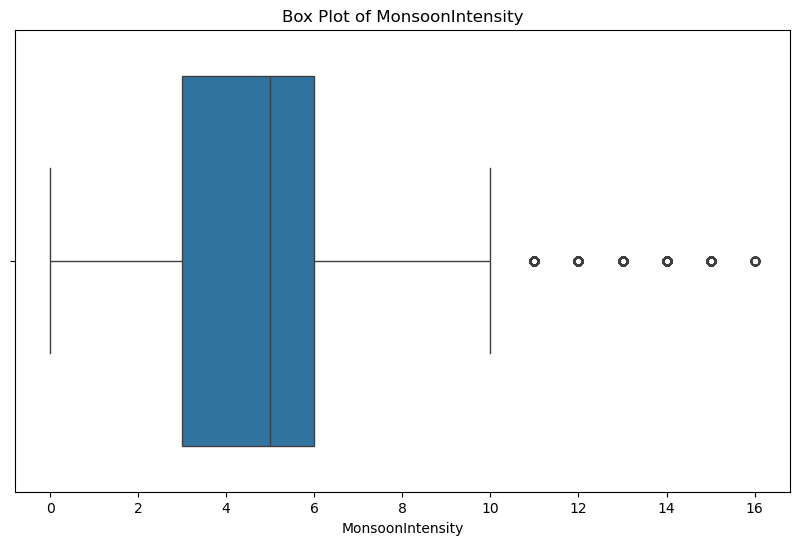

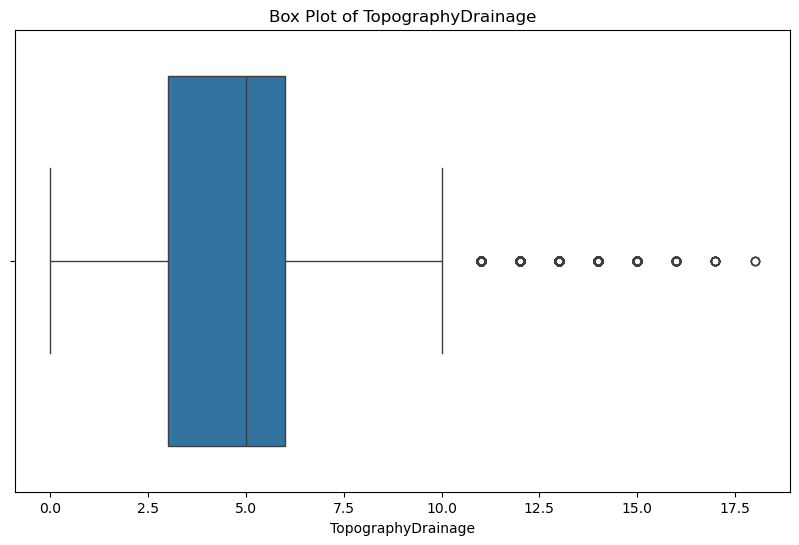

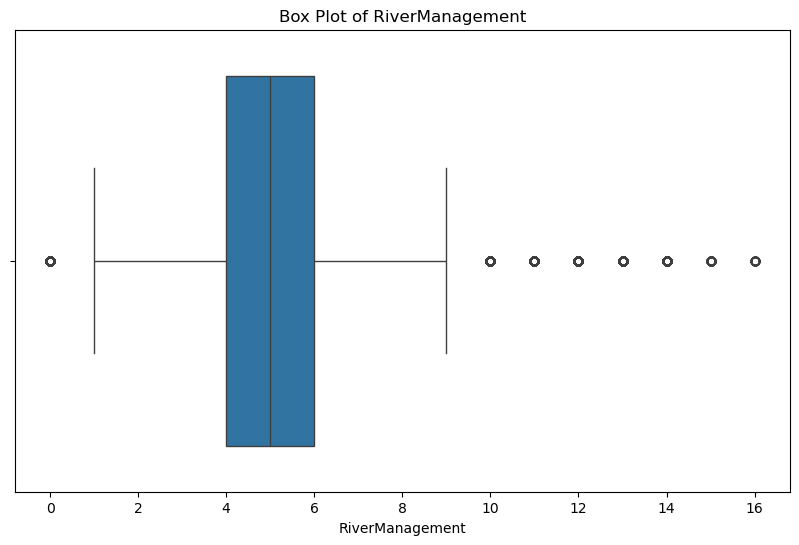

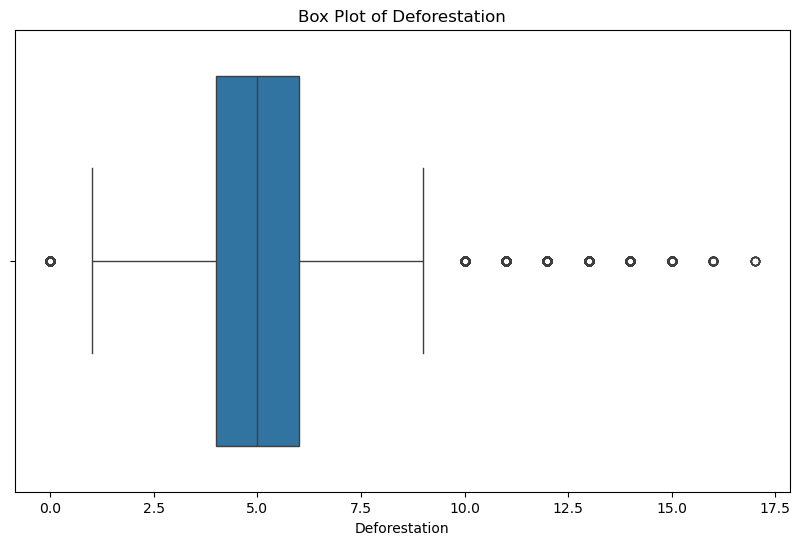

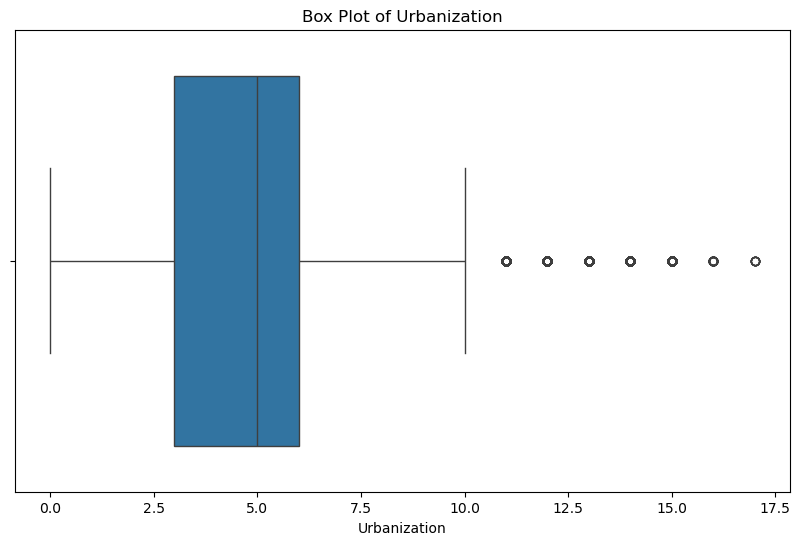

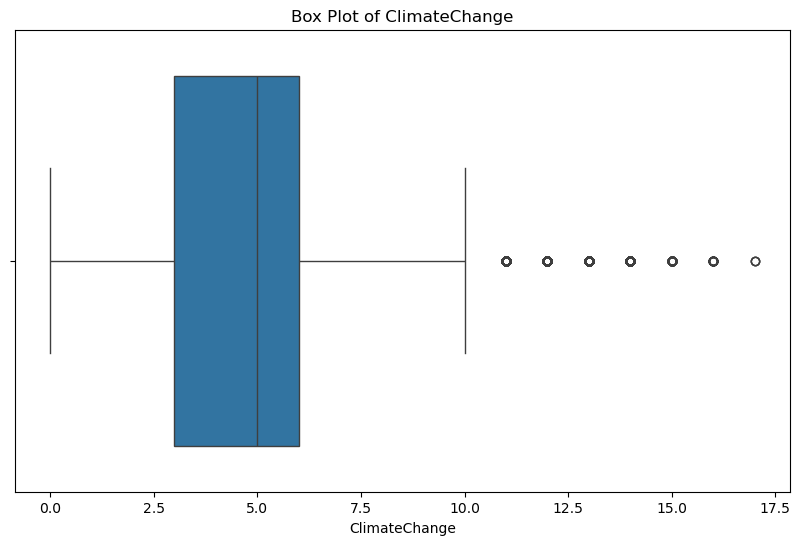

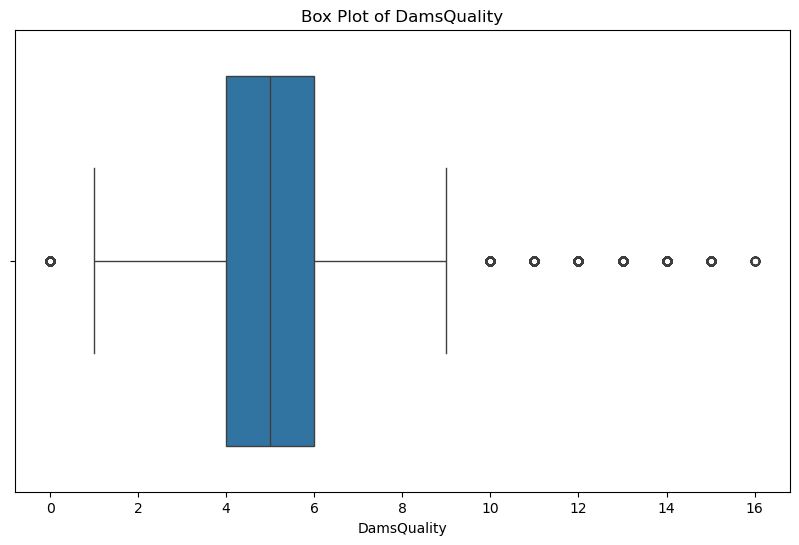

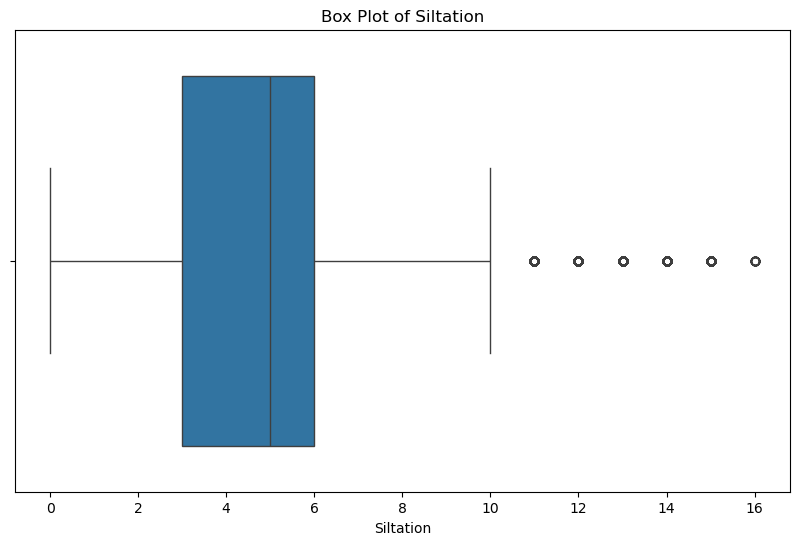

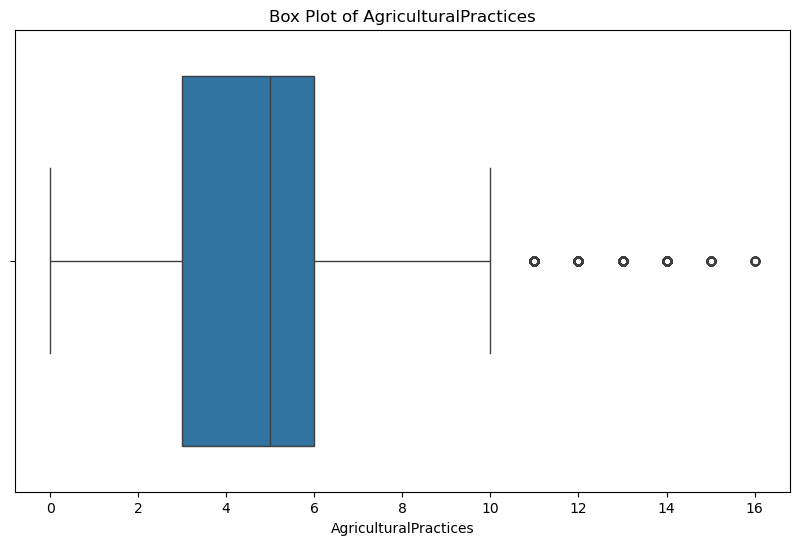

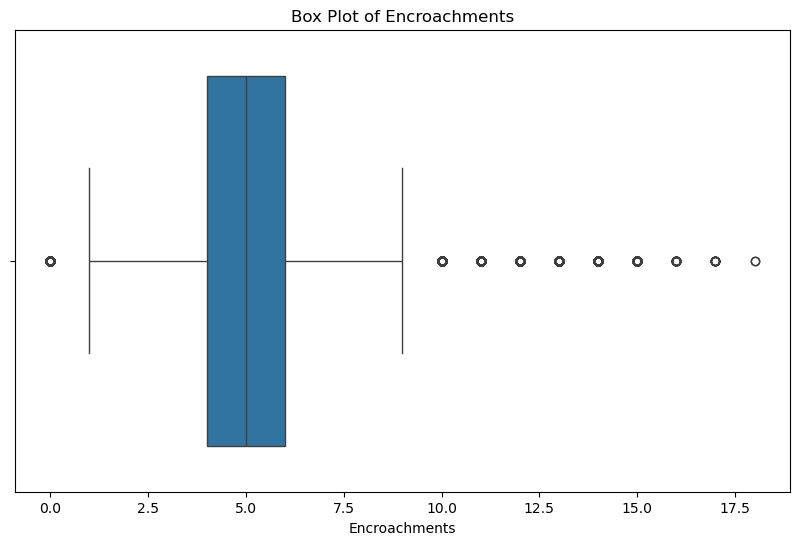

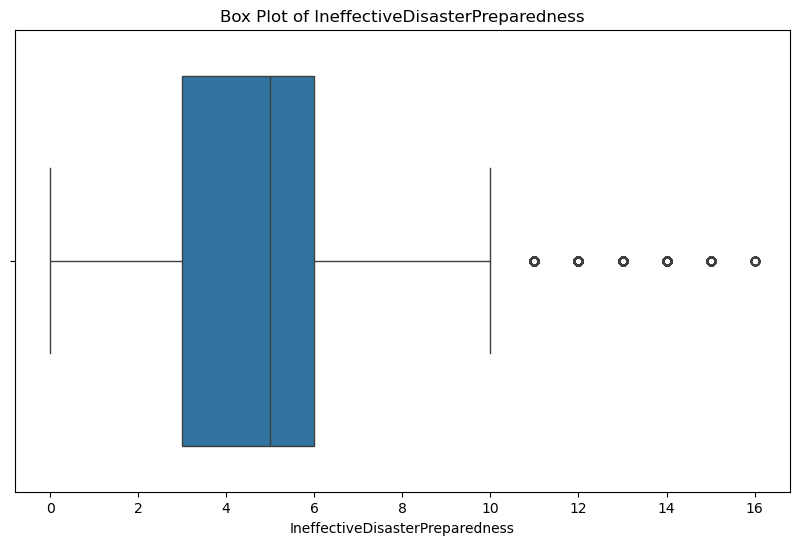

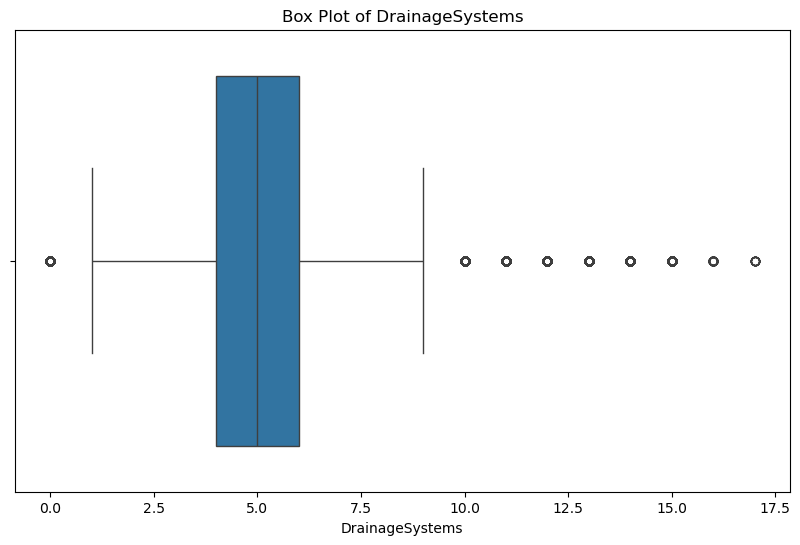

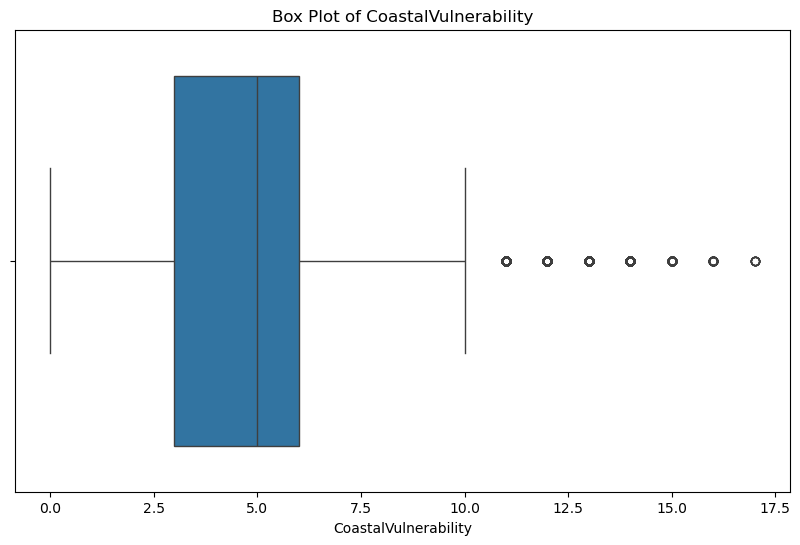

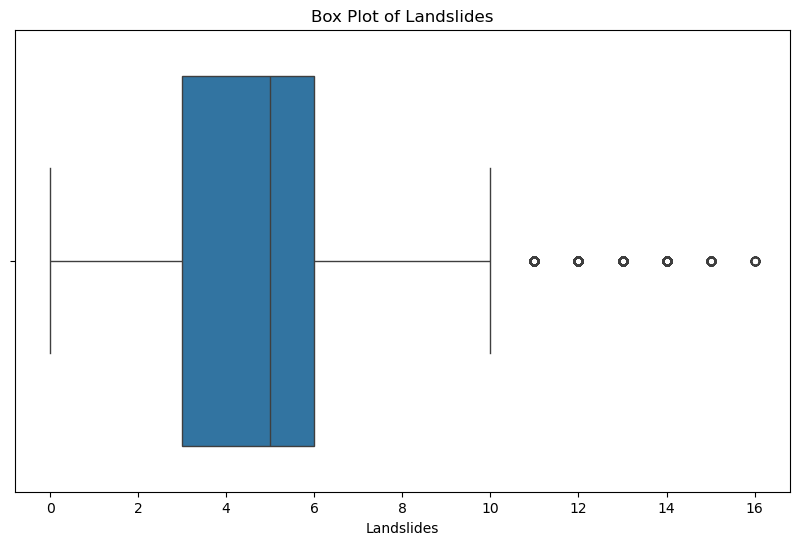

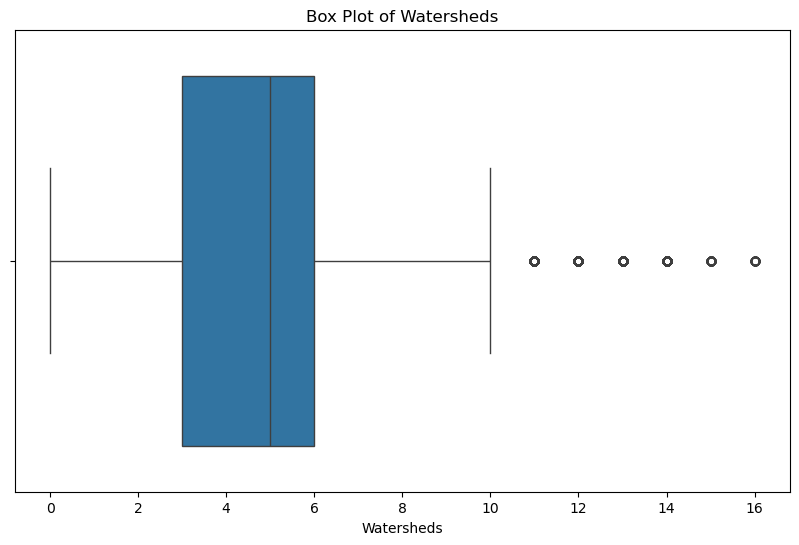

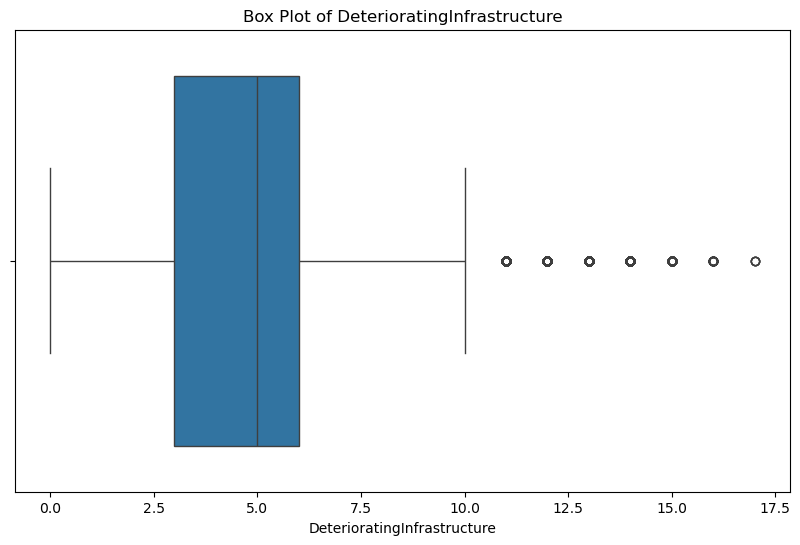

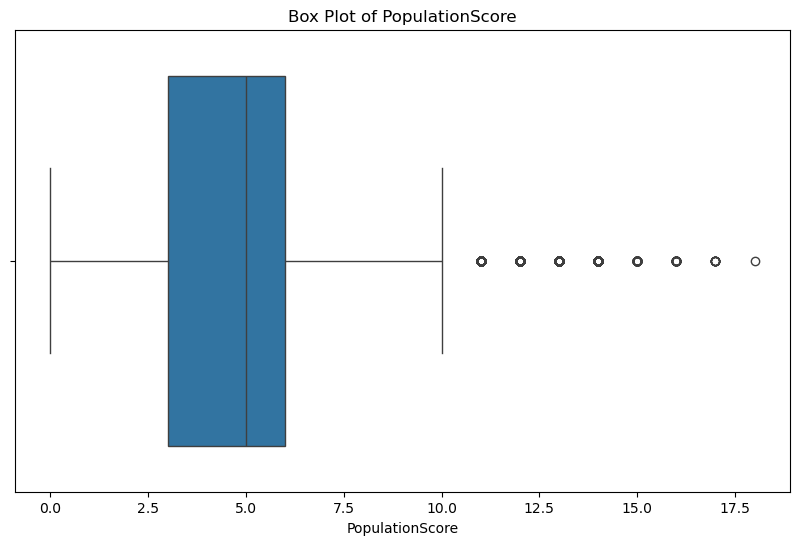

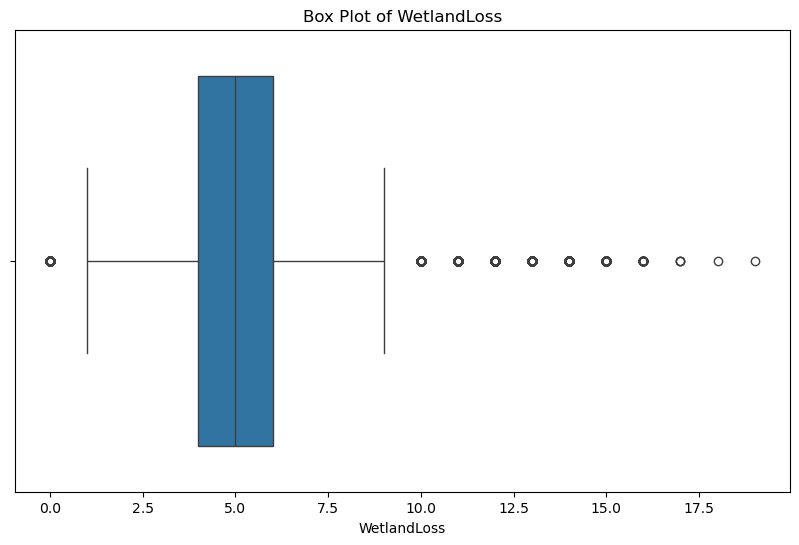

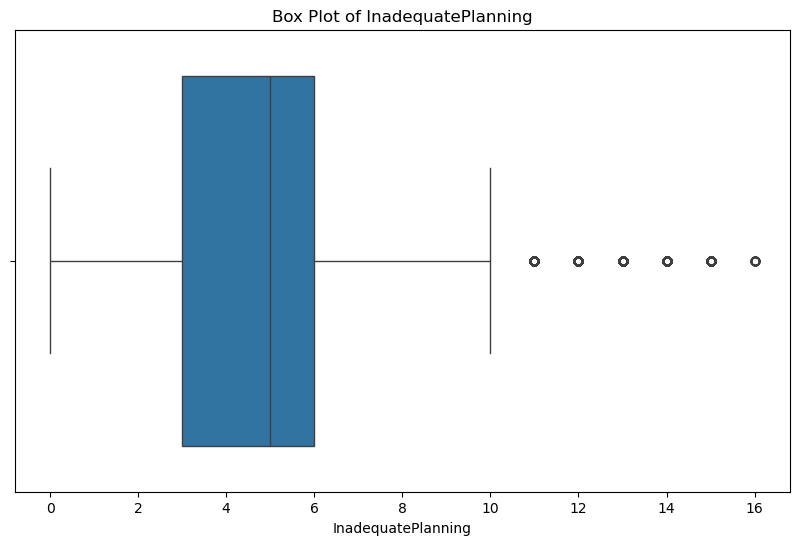

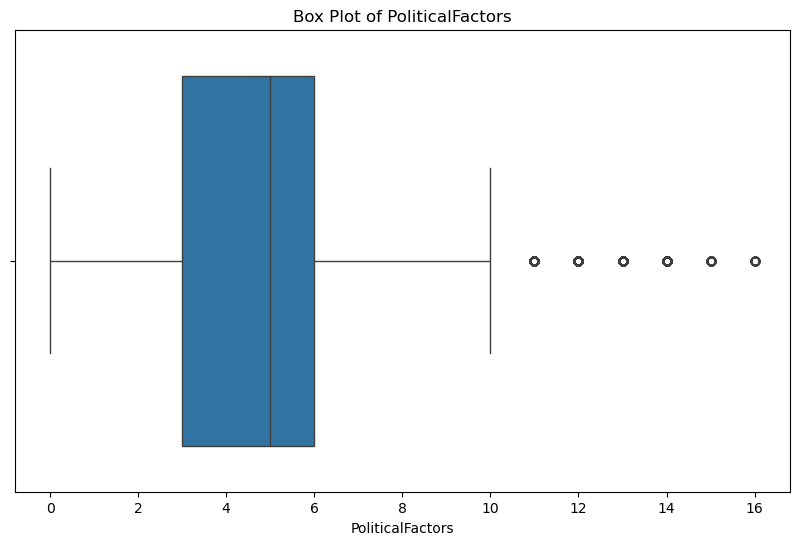

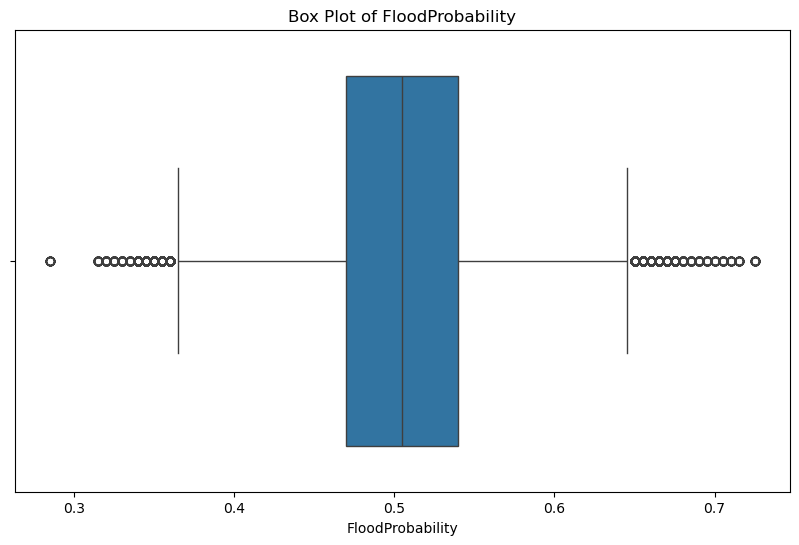

In [41]:
for feature in df_train.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df_train[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

In [47]:
# Mengidentifikasi outliers menggunakan IQR
Q1 = df_train.quantile(0.25)
Q3 = df_train.quantile(0.75)
IQR = Q3 - Q1

# Filter dataframe untuk hanya menyimpan baris yang tidak mengandung outliers pada kolom numerik
condition = ~((df_train < (Q1 - 1.5 * IQR)) | (df_train > (Q3 + 1.5 * IQR))).any(axis=1)
df = df_train.loc[condition, df_train.columns]

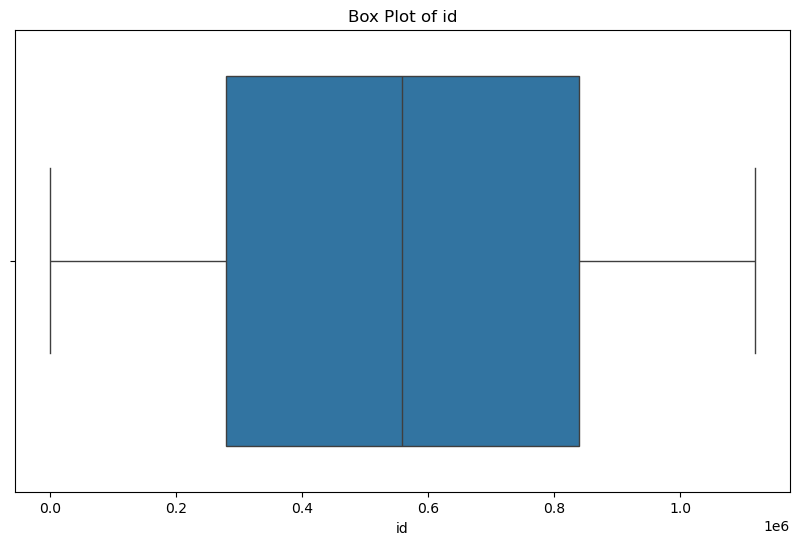

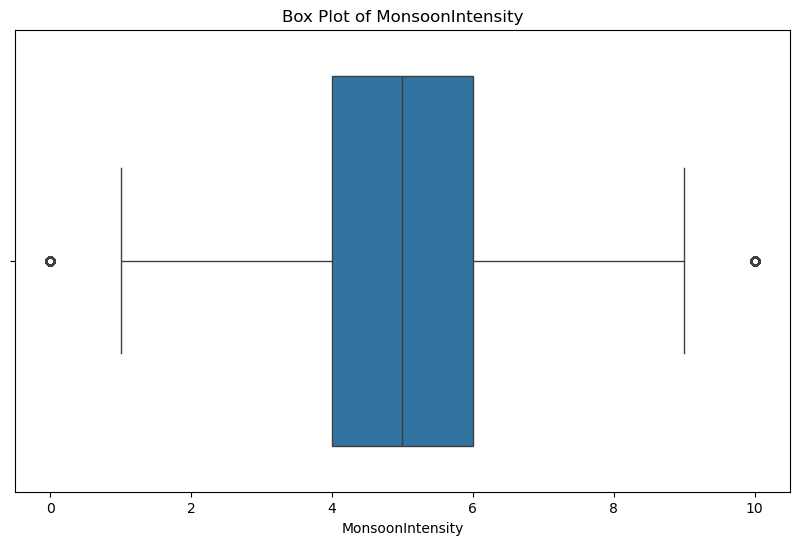

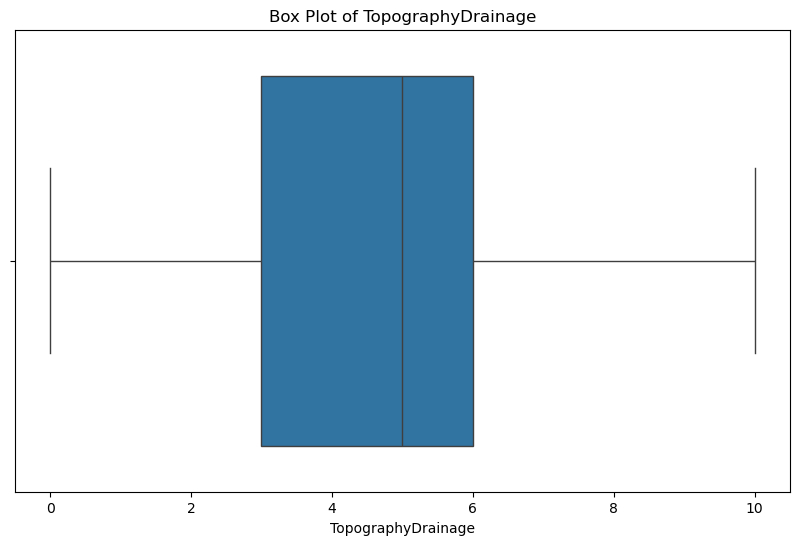

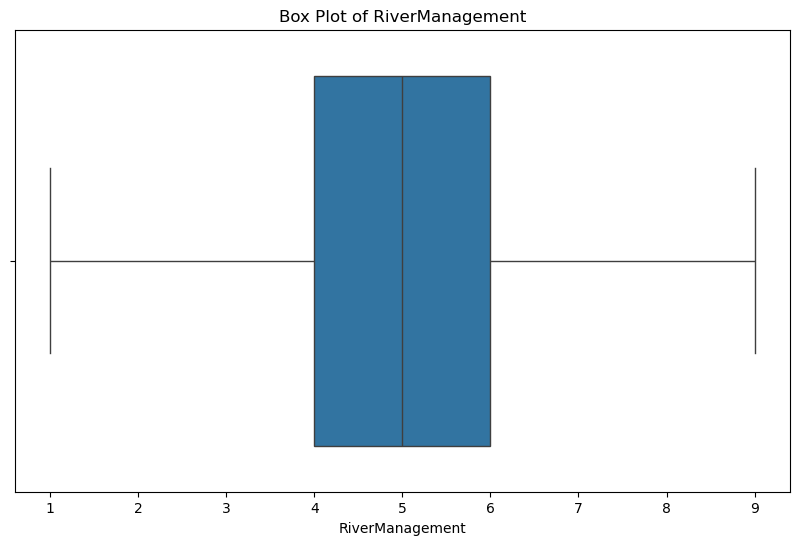

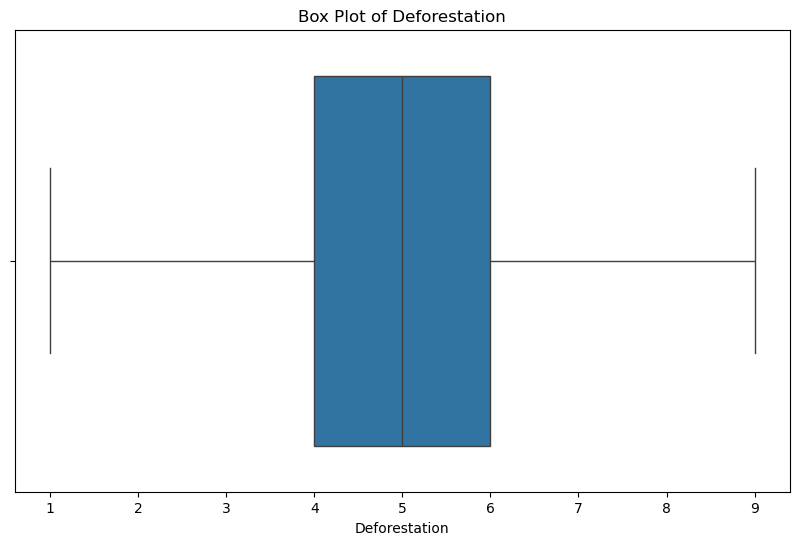

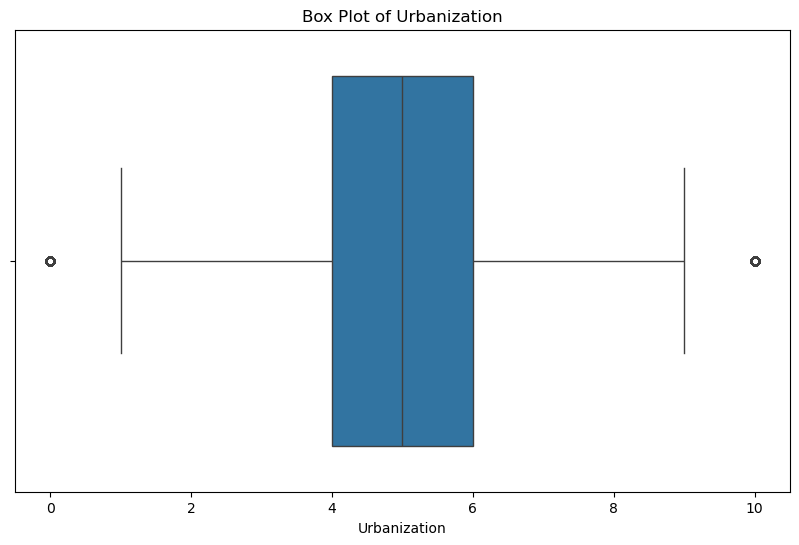

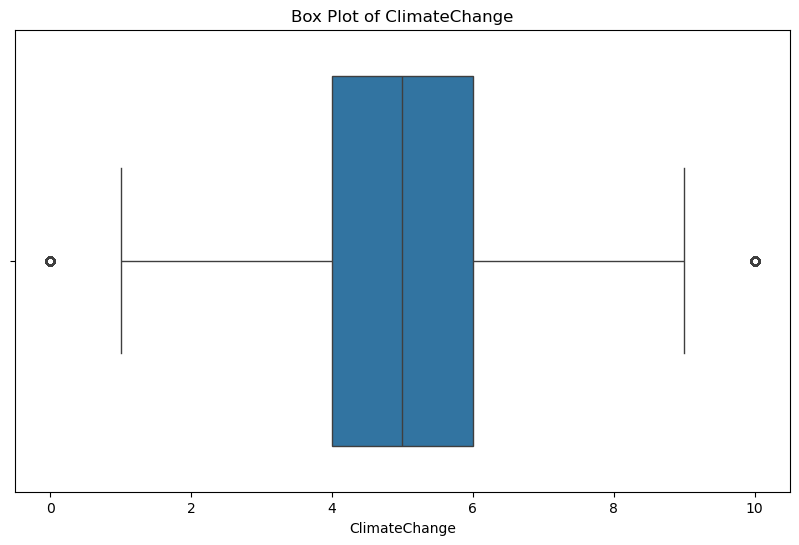

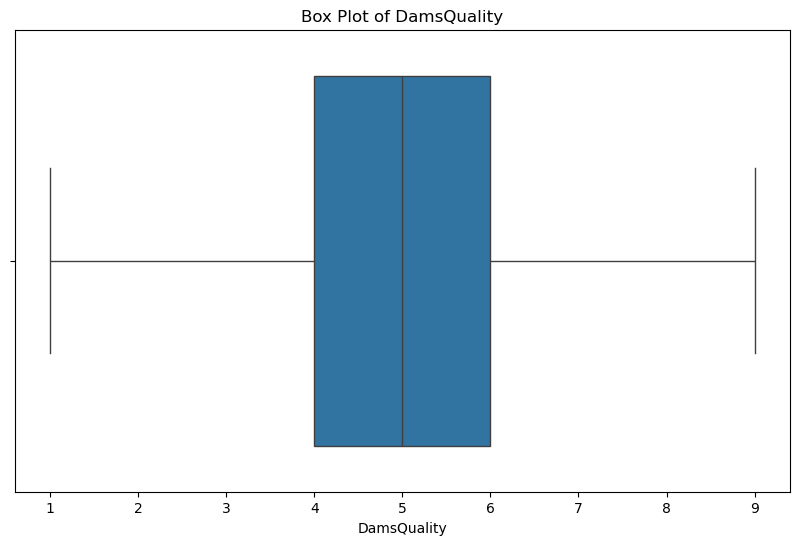

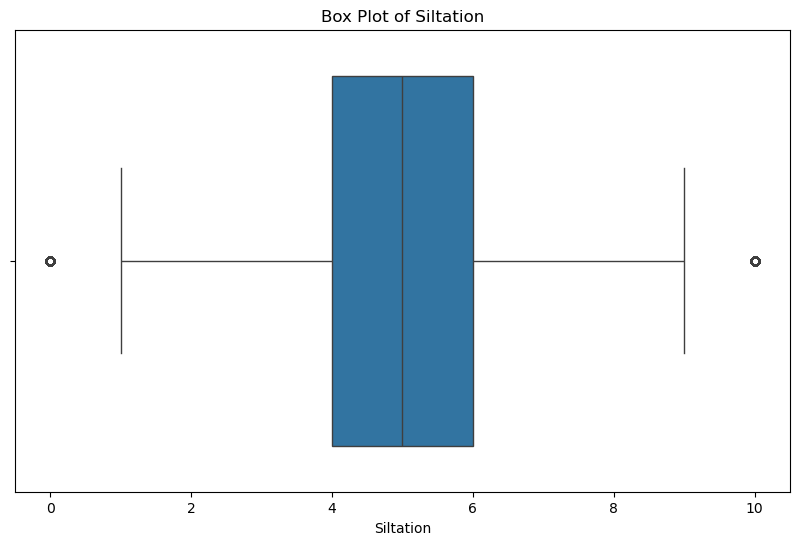

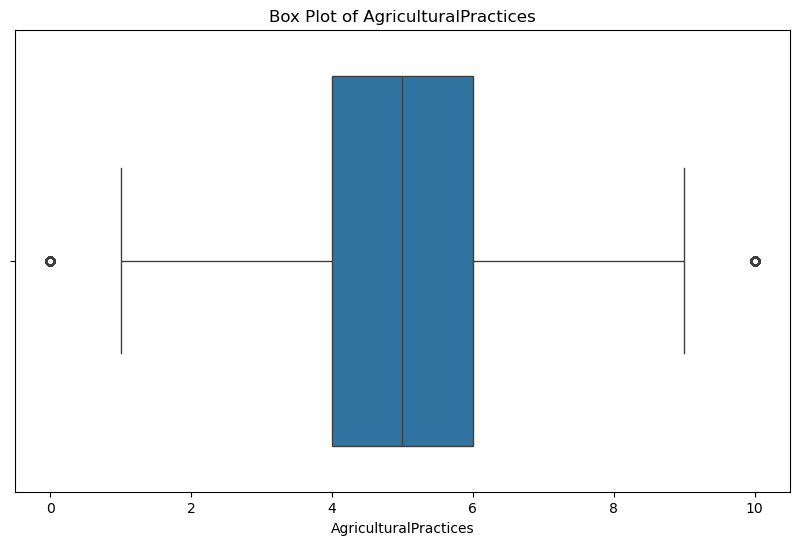

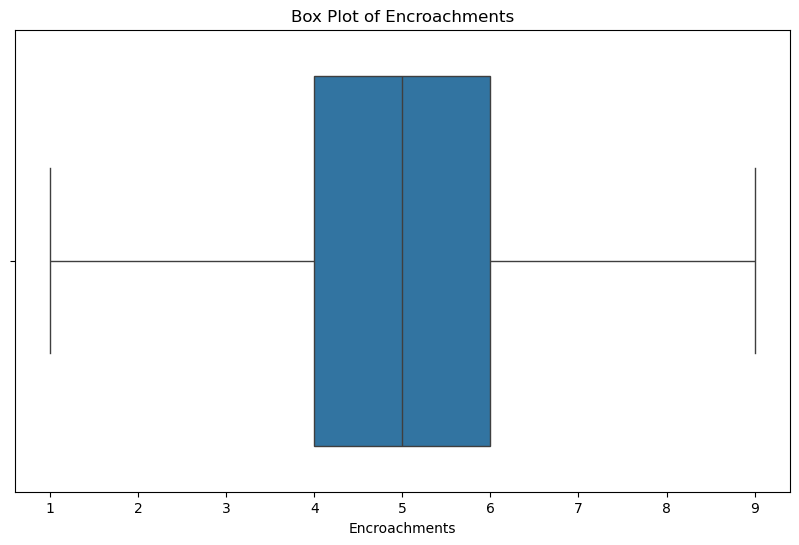

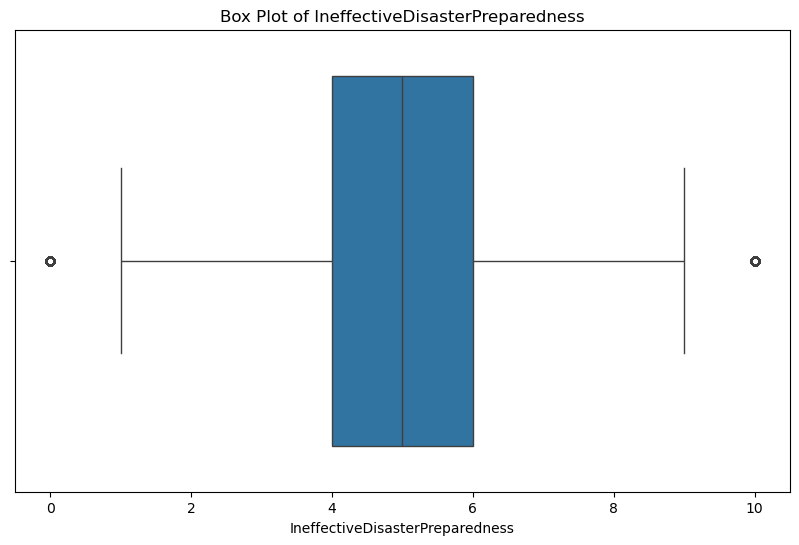

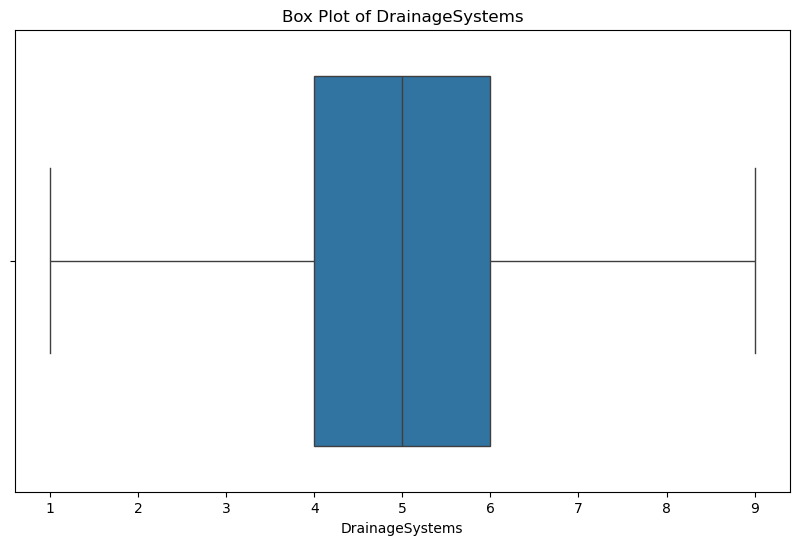

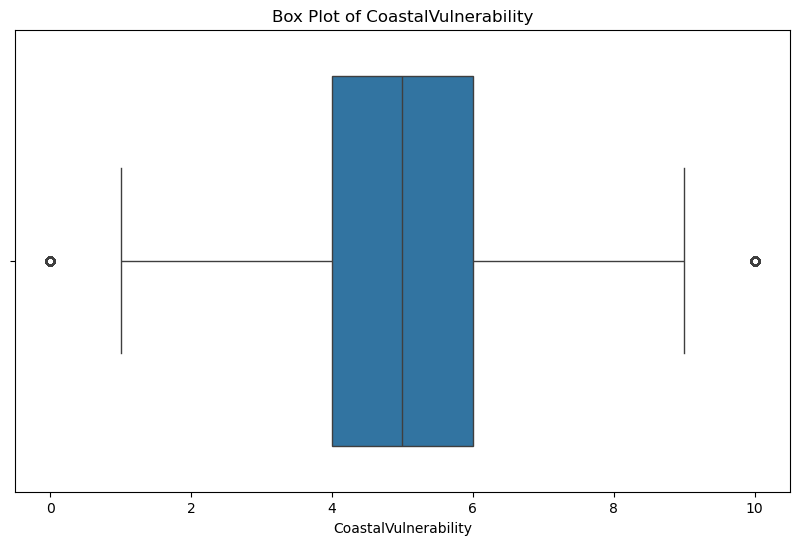

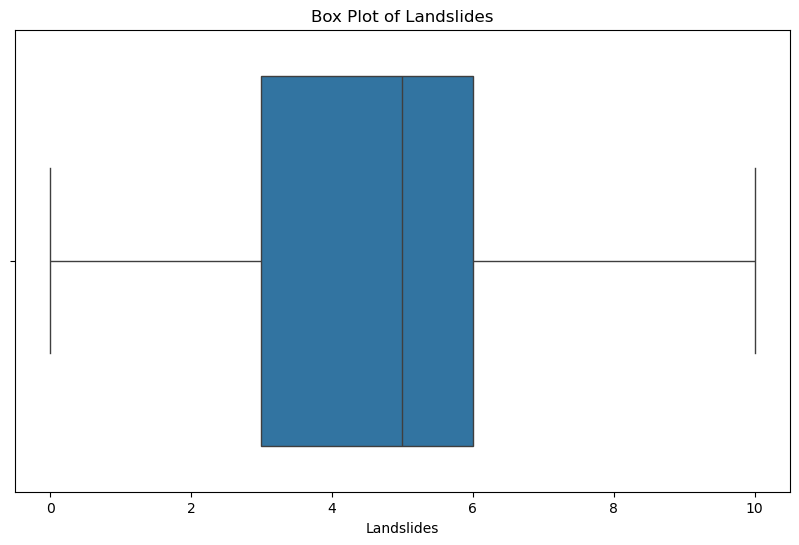

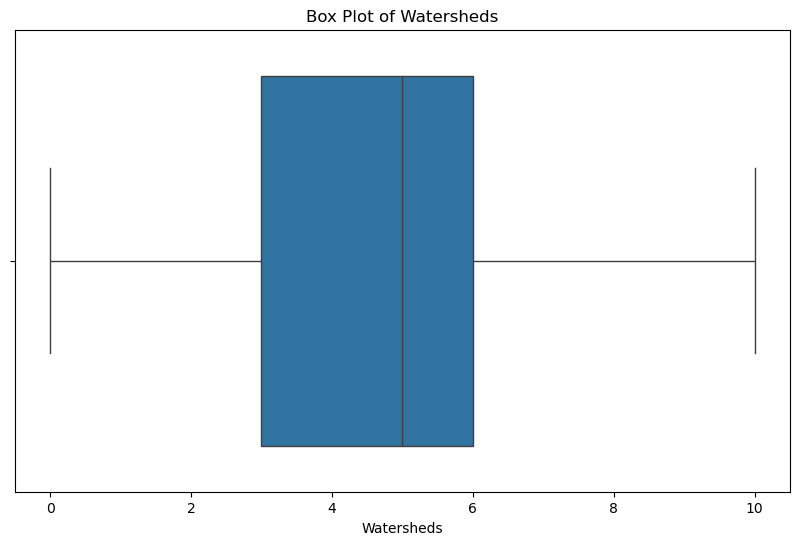

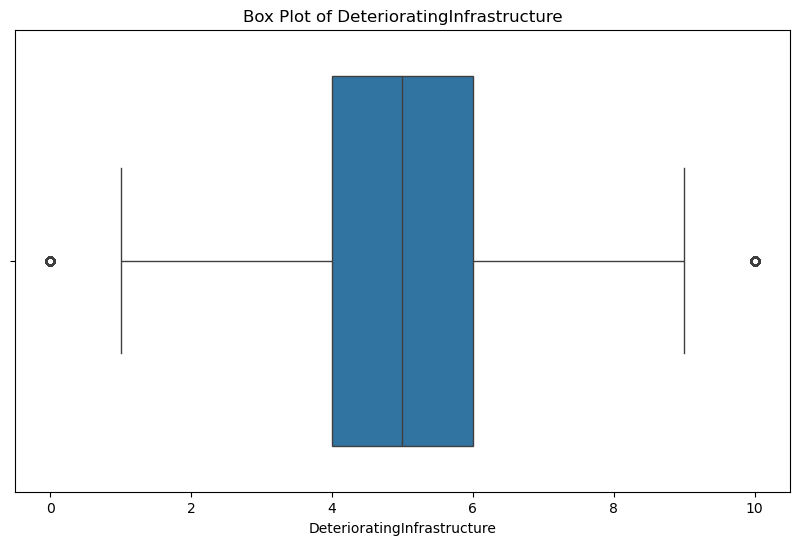

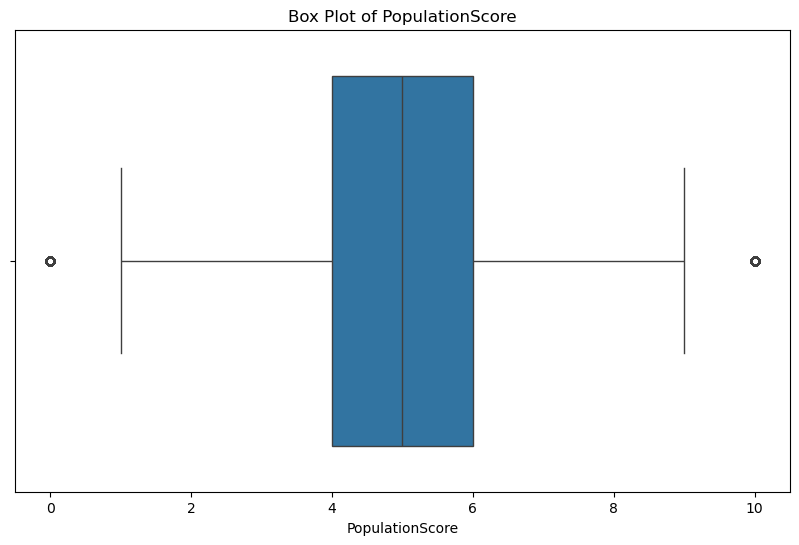

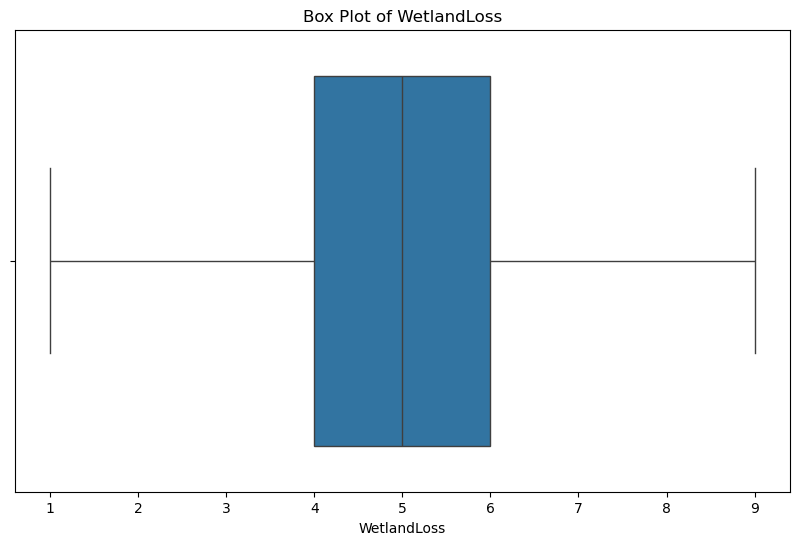

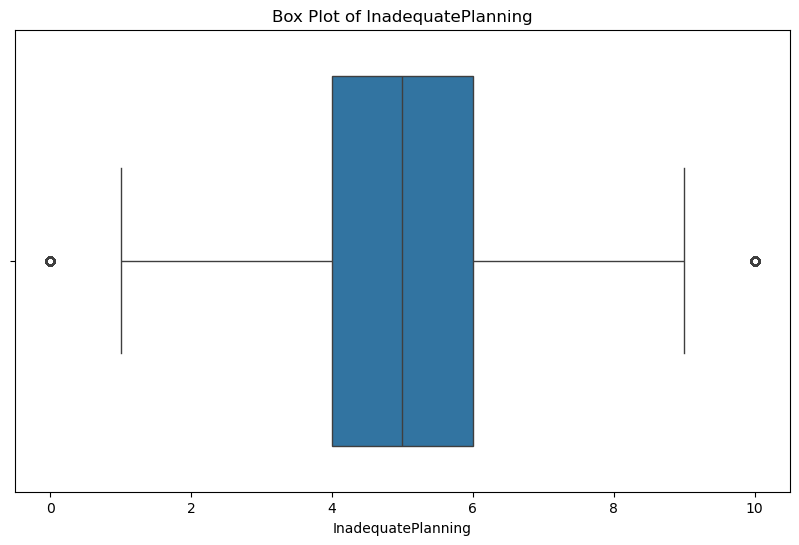

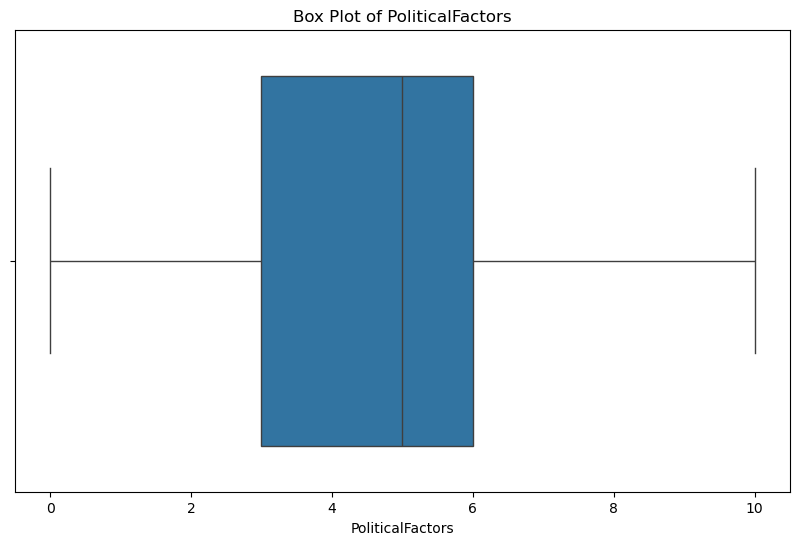

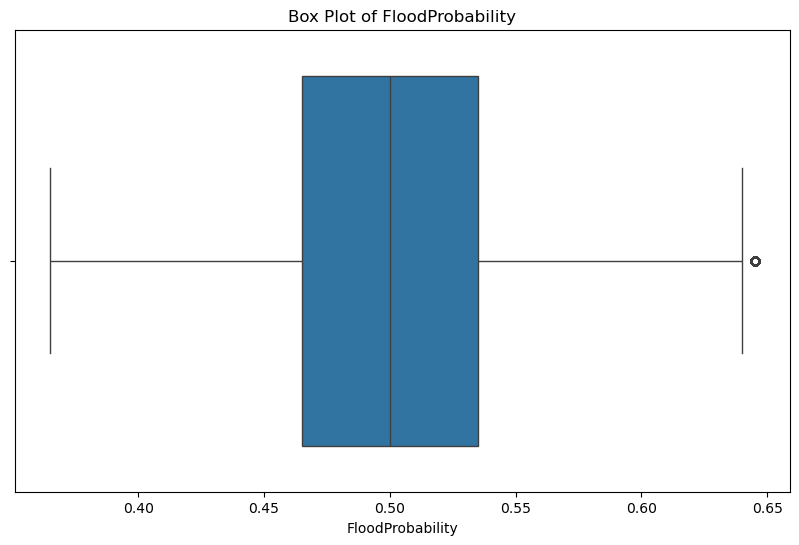

In [49]:
for feature in df.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

In [51]:
from sklearn.preprocessing import StandardScaler

# Memastikan hanya data dengan tipe numerikal yang akan diproses 
numeric_features = df.select_dtypes(include=['number']).columns
numeric_features

# Standarisasi fitur numerik
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

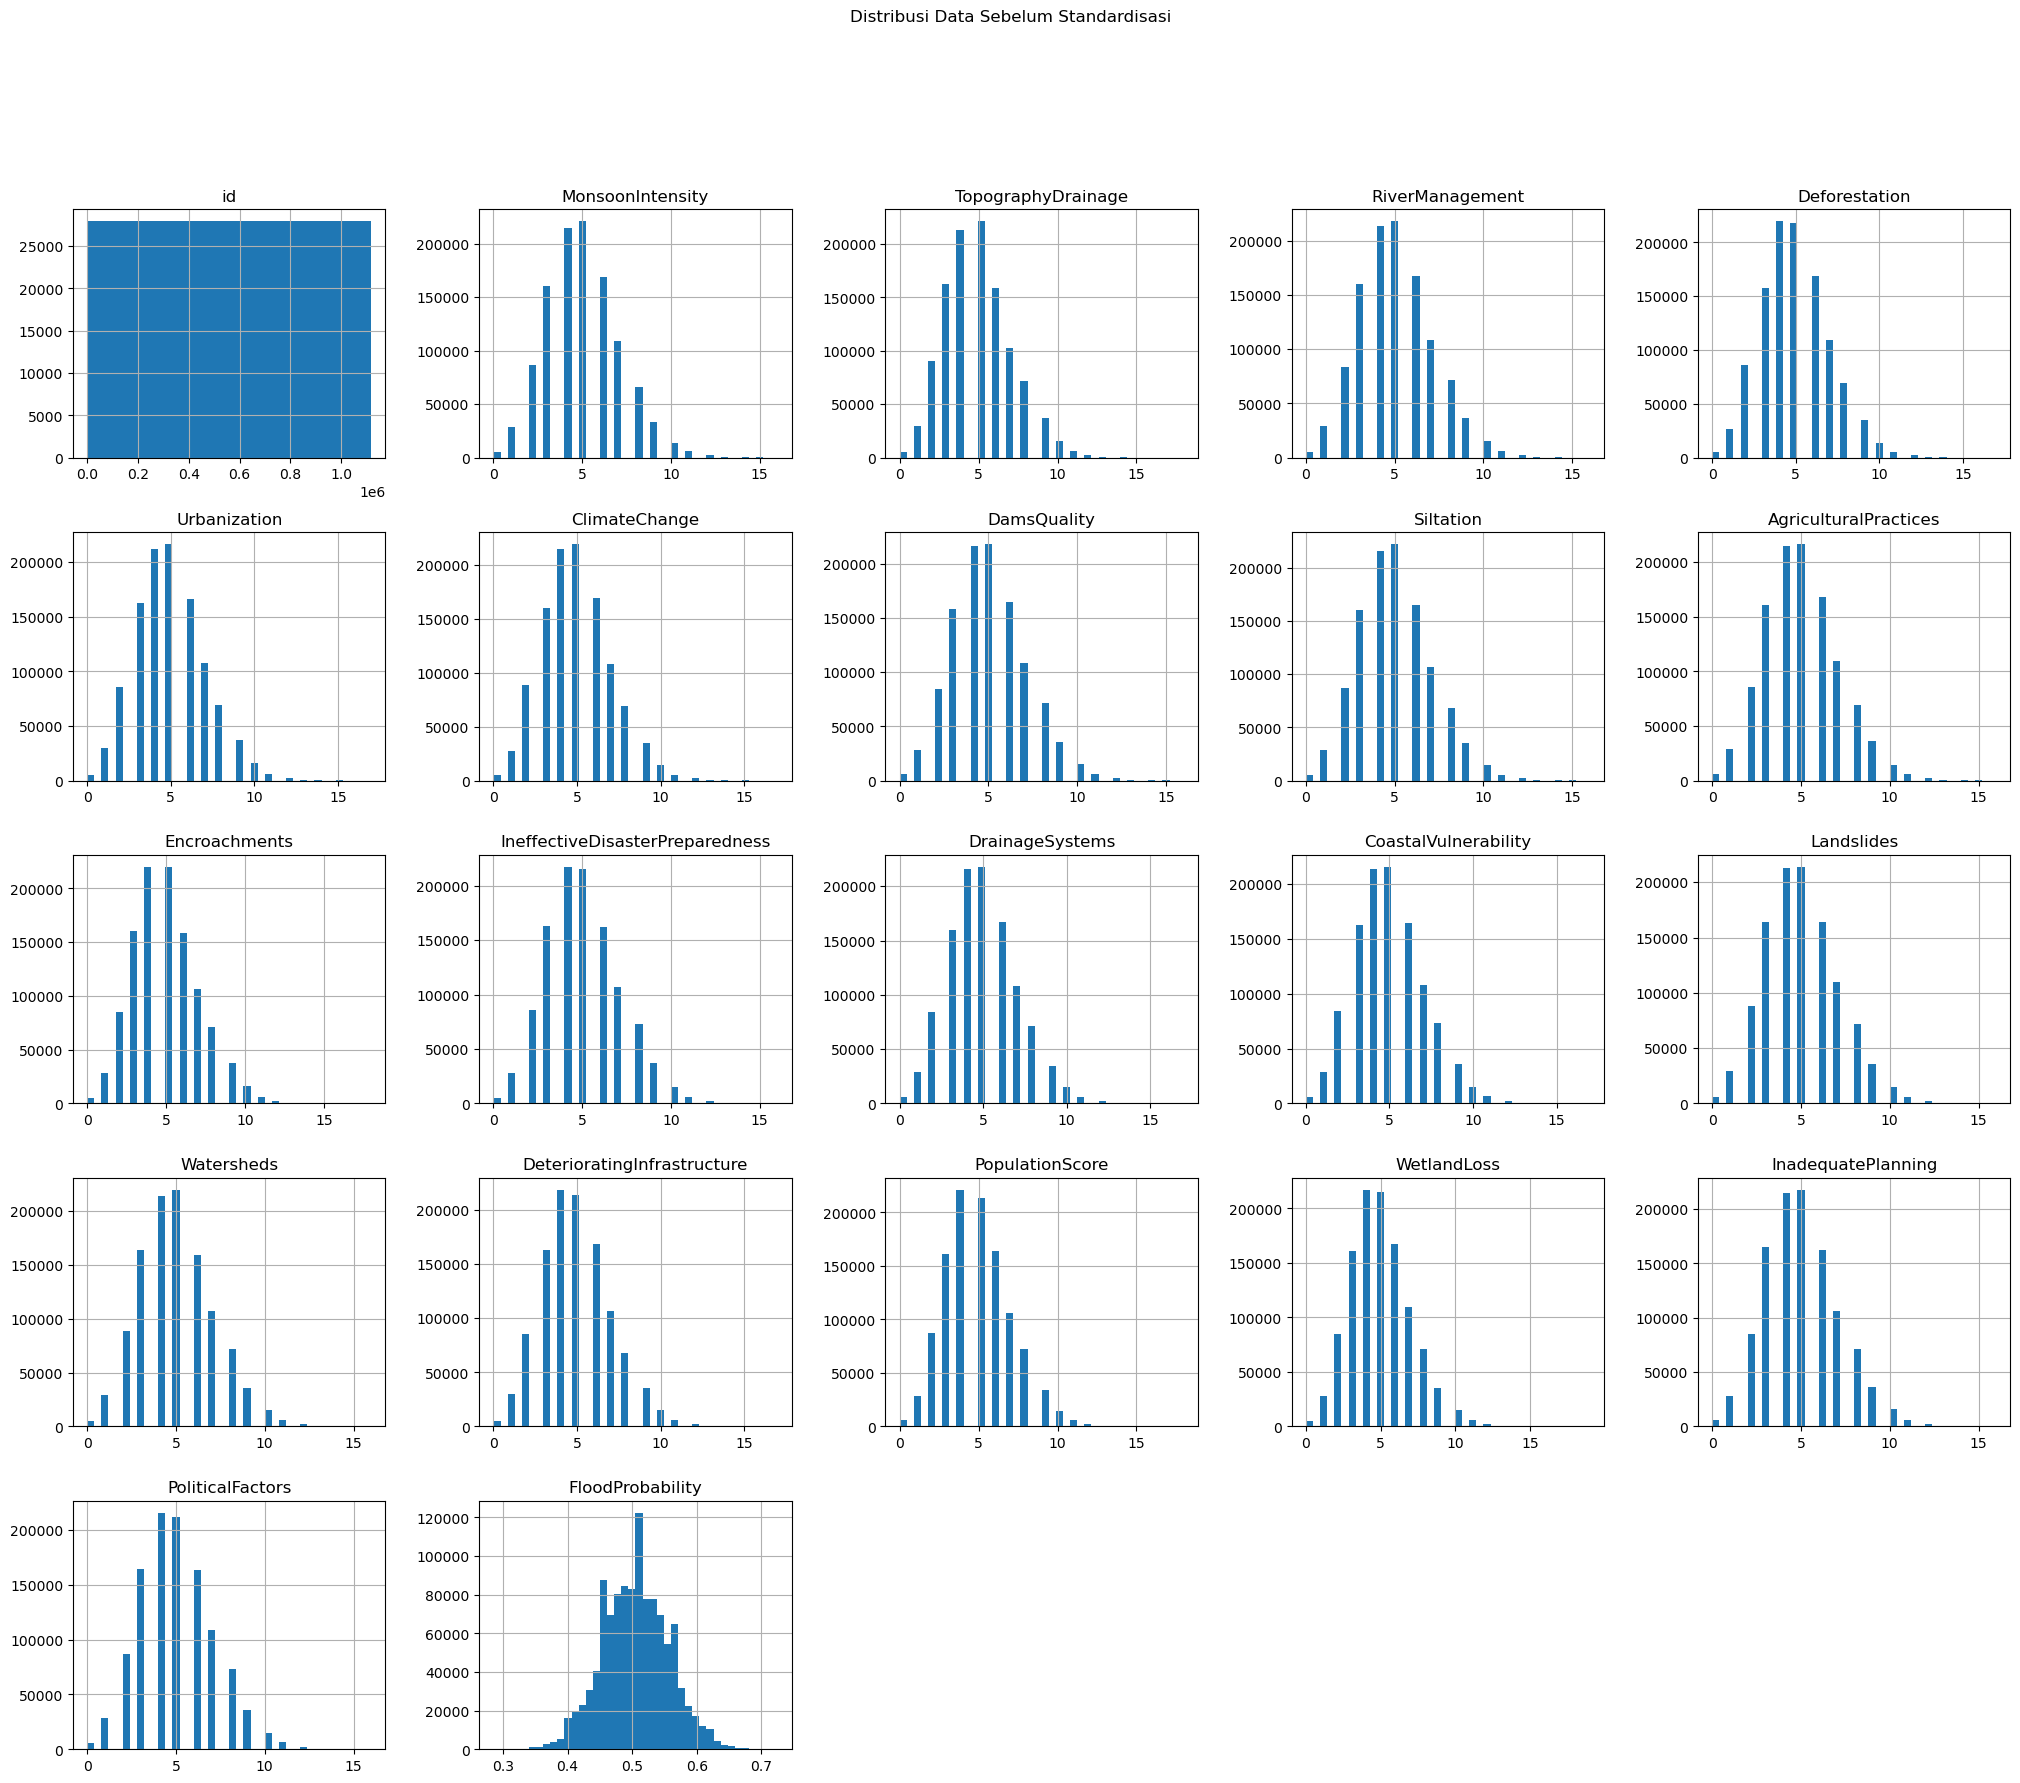

In [65]:
df_train.hist(figsize=(25, 20), bins=40)
plt.suptitle("Distribusi Data Sebelum Standardisasi")
plt.show()

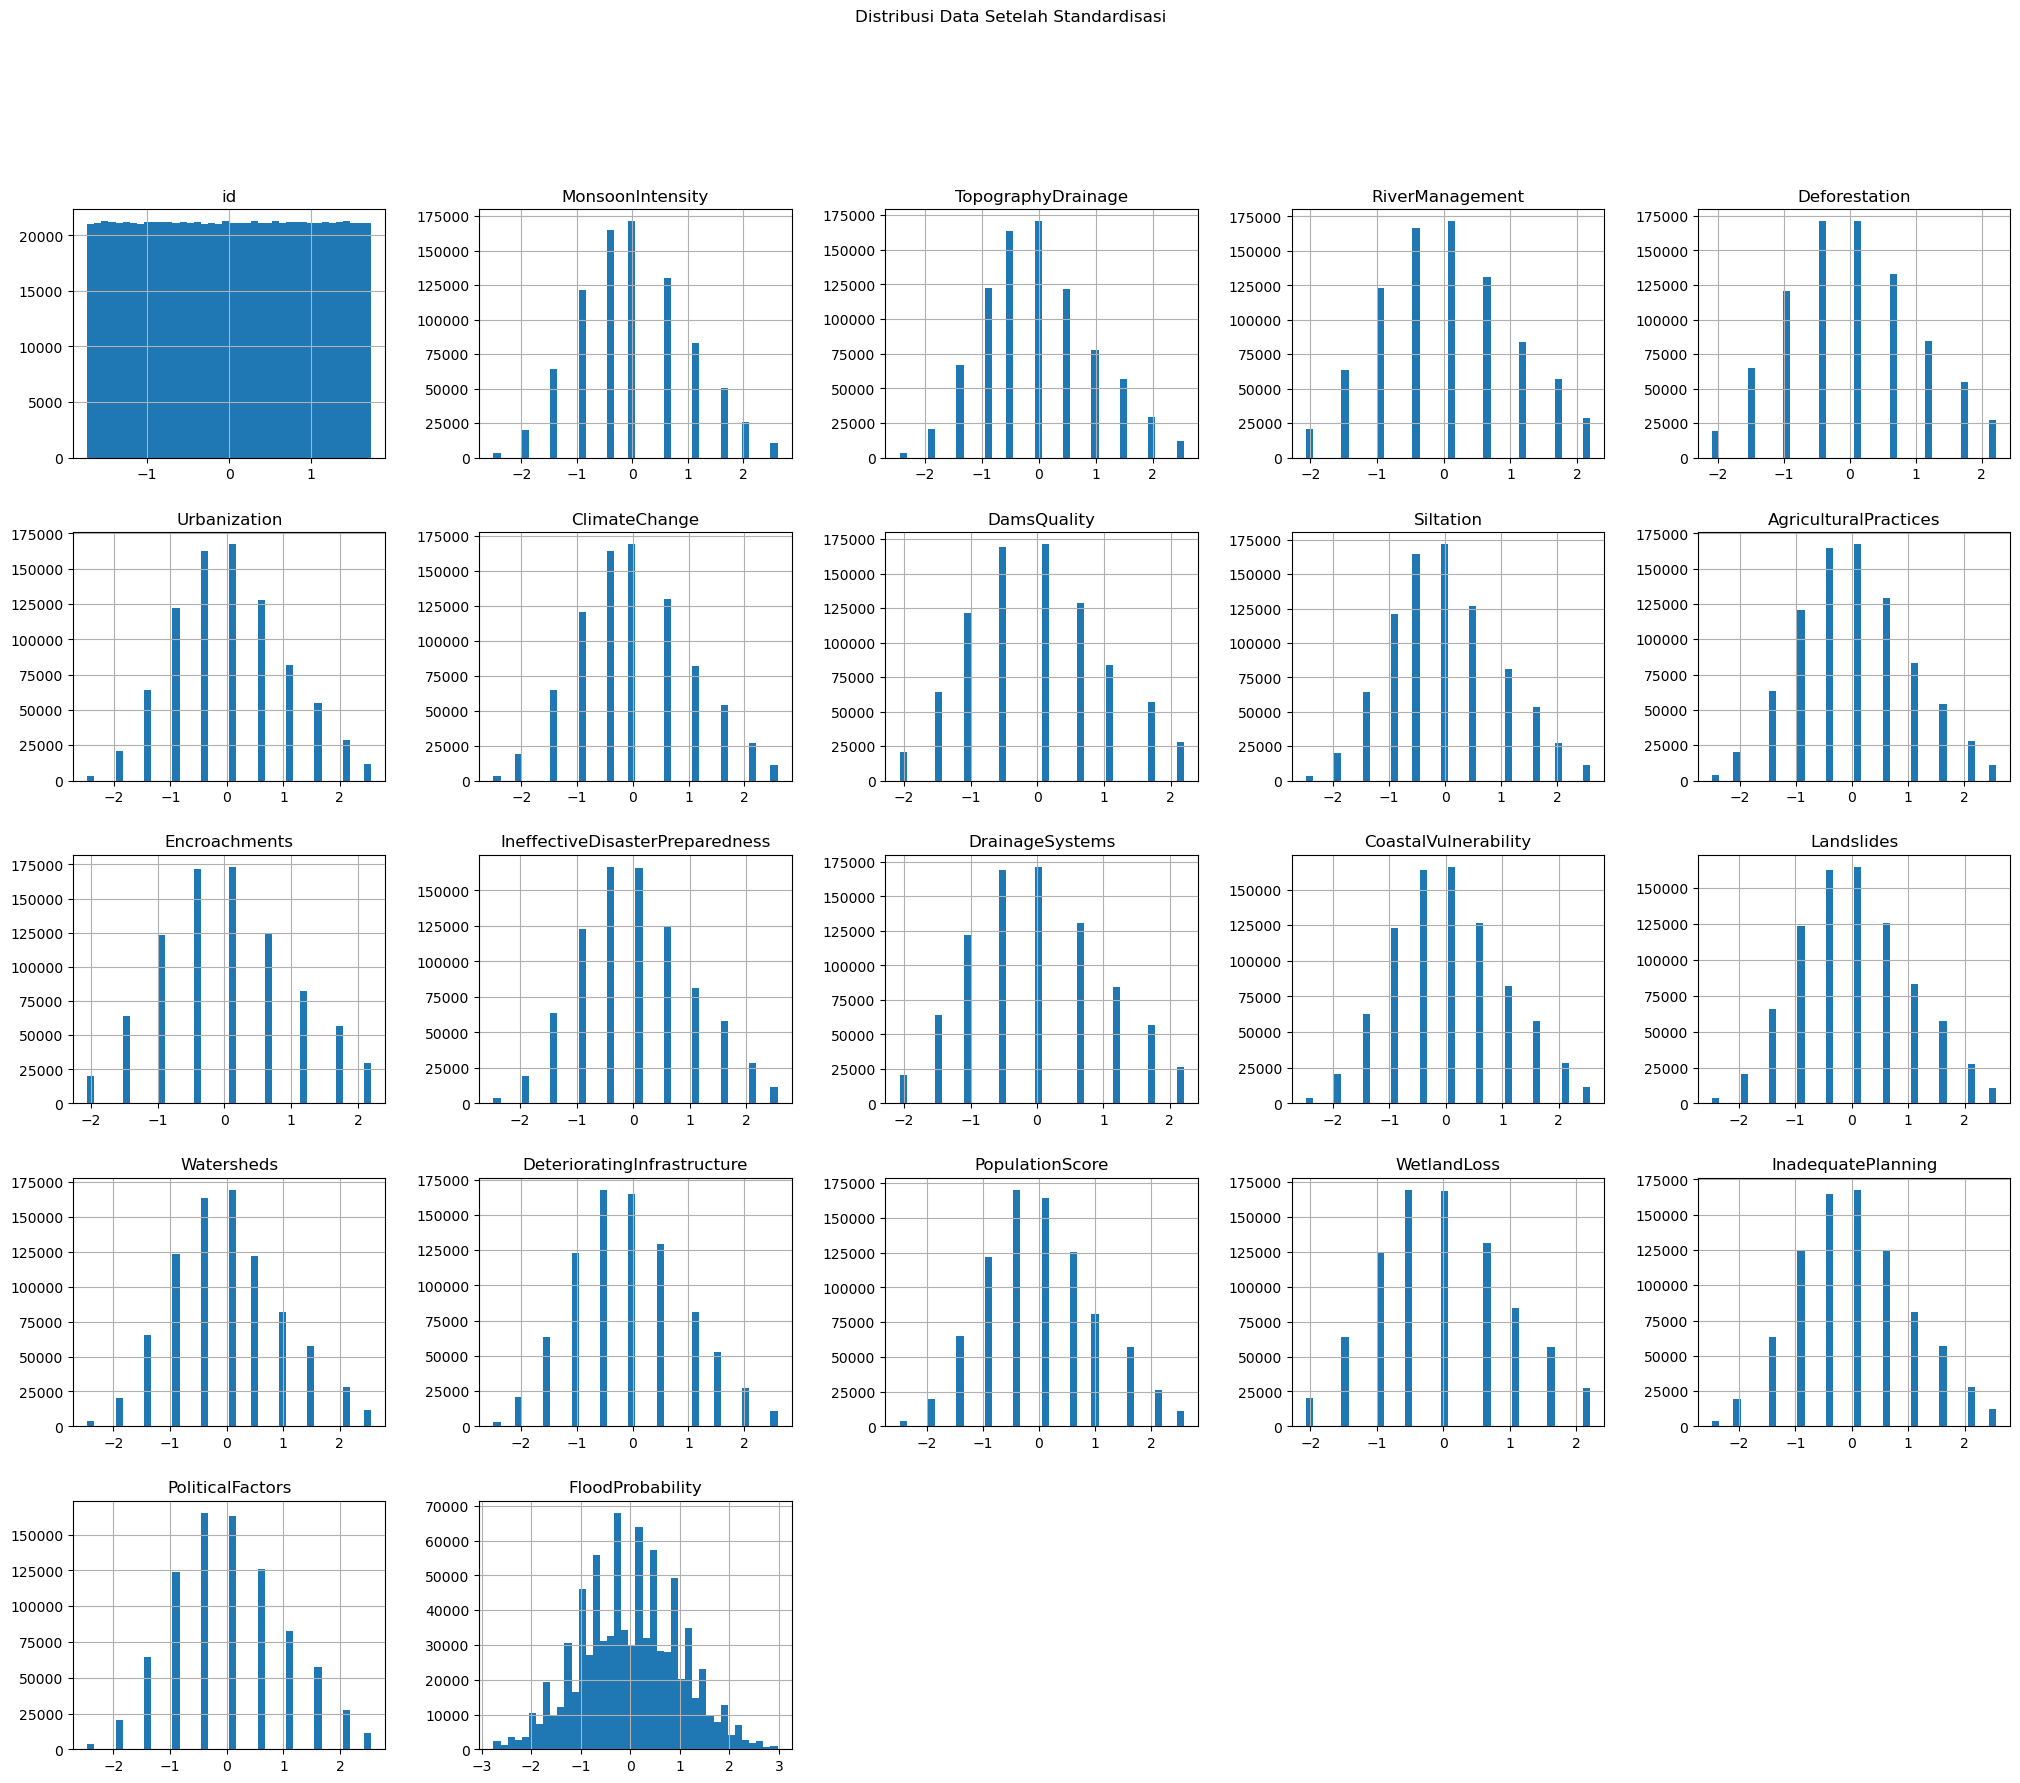

In [67]:
df.hist(figsize=(25, 20), bins=40)
plt.suptitle("Distribusi Data Setelah Standardisasi")
plt.show()

In [69]:
# Identifikasi baris duplikat
duplicates = df.duplicated()

print('Baris duplikat:')
print(df[duplicates])

Baris duplikat:
Empty DataFrame
Columns: [id, MonsoonIntensity, TopographyDrainage, RiverManagement, Deforestation, Urbanization, ClimateChange, DamsQuality, Siltation, AgriculturalPractices, Encroachments, IneffectiveDisasterPreparedness, DrainageSystems, CoastalVulnerability, Landslides, Watersheds, DeterioratingInfrastructure, PopulationScore, WetlandLoss, InadequatePlanning, PoliticalFactors, FloodProbability]
Index: []


## Data Exploratory and Explanatory

In [72]:
df.describe(include='all')

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00,845886.00
mean,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.73,-2.50,-2.45,-2.07,-2.08,-2.47,-2.50,-2.06,-2.49,-2.49,-2.06,-2.47,-2.07,-2.48,-2.47,-2.46,-2.49,-2.48,-2.07,-2.47,-2.46,-2.76
25%,-0.87,-0.45,-0.95,-0.47,-0.47,-0.46,-0.46,-0.47,-0.46,-0.46,-0.46,-0.46,-0.46,-0.46,-0.96,-0.96,-0.45,-0.45,-0.47,-0.46,-0.96,-0.71
50%,0.00,0.06,0.05,0.06,0.07,0.04,0.05,0.07,0.05,0.04,0.07,0.04,0.07,0.04,0.05,0.05,0.05,0.05,0.07,0.04,0.04,0.00
75%,0.87,0.57,0.55,0.60,0.61,0.54,0.56,0.60,0.56,0.55,0.60,0.54,0.61,0.54,0.55,0.55,0.56,0.56,0.60,0.55,0.55,0.72
max,1.73,2.62,2.55,2.19,2.22,2.55,2.59,2.20,2.59,2.57,2.20,2.55,2.21,2.55,2.56,2.56,2.59,2.58,2.20,2.56,2.55,2.97


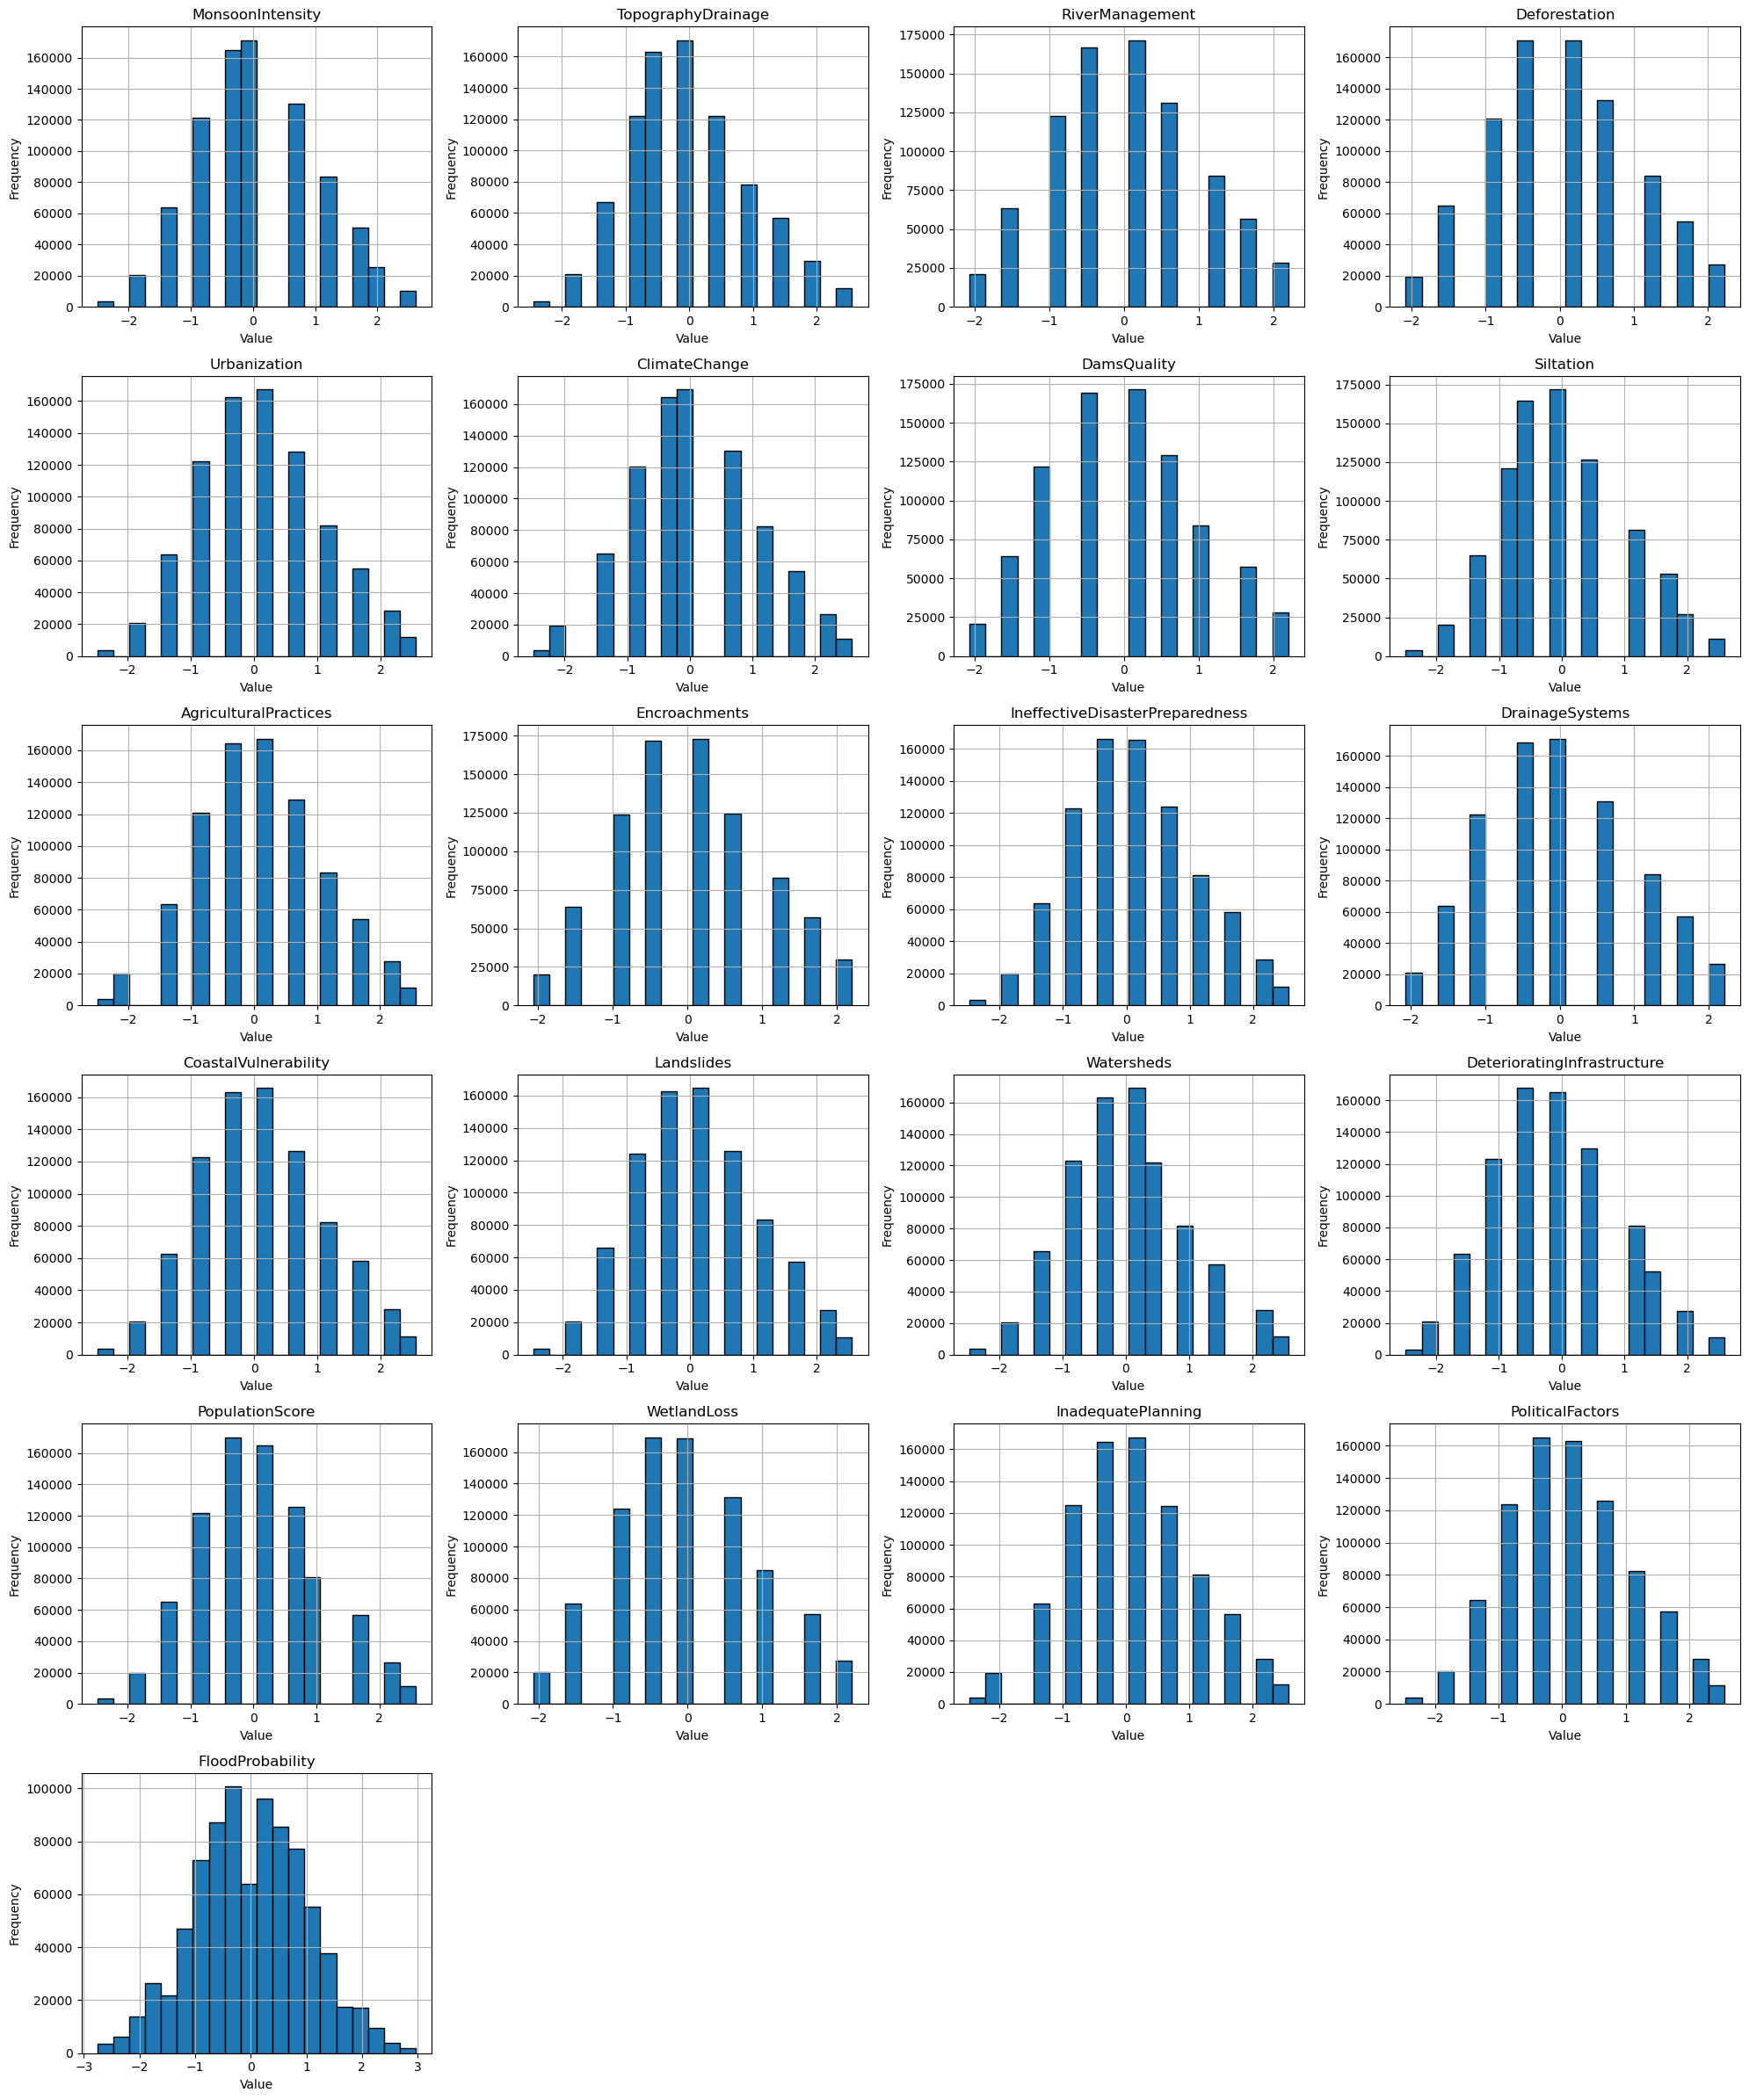

In [76]:
# Menghitung jumlah variabel
num_vars = df.shape[1]
 
# Menentukan jumlah baris dan kolom untuk grid subplot
n_cols = 4  # Jumlah kolom yang diinginkan
n_rows = -(-num_vars // n_cols)  # Ceiling division untuk menentukan jumlah baris
 
# Membuat subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
 
# Flatten axes array untuk memudahkan iterasi jika diperlukan
axes = axes.flatten()
 
# Plot setiap variabel
for i, column in enumerate(df.drop(columns=["id"]).columns):
    df[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
 
# Menghapus subplot yang tidak terpakai (jika ada)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
 
# Menyesuaikan layout agar lebih rapi
plt.tight_layout()
plt.show()

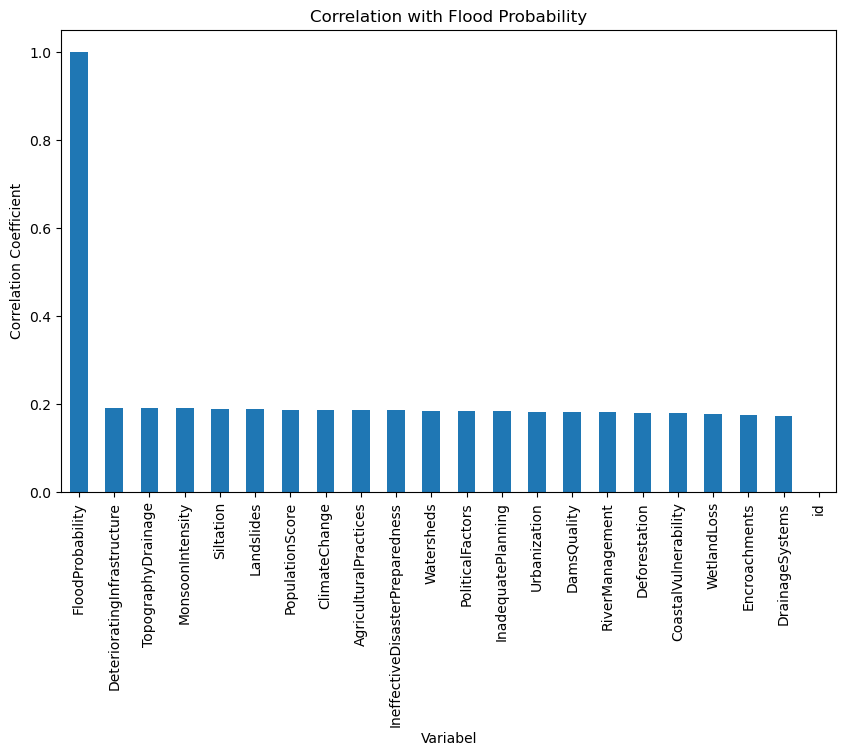

In [82]:
# Menghitung korelasi antara variabel target dan semua variabel lainnya
target_corr = df.corr()['FloodProbability']

# (opsional) mengurutkan hasil korelasi berdasarkan kekuatan korelasi
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with Flood Probability')
plt.xlabel('Variabel')
plt.ylabel('Correlation Coefficient')
plt.show()

## Data splitting

In [89]:
import sklearn
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Memisahkan fitur (X) dan target (y)
X = df.drop(columns=['FloodProbability'])
y = df['FloodProbability']

# membagi dataset menjadi training dan testing
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
 
# menghitung panjang/jumlah data
print("Jumlah data: ",len(X))
# menghitung panjang/jumlah data pada x_train
print("Jumlah data latih: ",len(x_train))
# menghitung panjang/jumlah data pada x_test
print("Jumlah data test: ",len(x_test))

Jumlah data:  845886
Jumlah data latih:  676708
Jumlah data test:  169178


## Pelatihan model

In [92]:
from sklearn import linear_model
lars = linear_model.Lars(n_nonzero_coefs=1).fit(x_train, y_train)
 
pred_lars = lars.predict(x_test)

In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_lars = mean_absolute_error(y_test, pred_lars)
mse_lars = mean_squared_error(y_test, pred_lars)
r2_lars = r2_score(y_test, pred_lars)
 
print(f"MAE: {mae_lars}")
print(f"MSE: {mse_lars}")
print(f"R²: {r2_lars}")

MAE: 0.8064965862112844
MSE: 0.9982455301765661
R²: 0.0007638833508322174
